In [1]:
import matplotlib.pyplot as plt
import os
import pandas as pd
import scanpy as sc
import squidpy as sq
import cv2
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
import numpy as np

from pathlib import Path

# import sys
# sys.path.append('/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/workflow/scripts')
# import coda
# import readwrite
# cfg = readwrite.config()

import sys
sys.path.append("/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/lmcconn1")
from norkin_organoid.code.get_embeddings import (
    NorkinOrganoidDataset,
)

%matplotlib inline
%load_ext autoreload
%autoreload 2

/work/PRTNR/CHUV/DIR/rgottar1/spatial/conda_envs/lazyslide_env/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/work/PRTNR/CHUV/DIR/rgottar1/spatial/conda_envs/lazyslide_env/lib/python3.11/site-packages/anndata/__init__.py:44: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)


# 0. Params and Settings

In [2]:
# ["run_1"]="1HVQ 1CNN 077I 1GAA 1J25 131N OWJ3 14PT"
# ["run_2"]="169V 1BI7 1CI5 1FMS 12NM OLR9 1GVB 1GNS"
ALIGNED_PATIENT_IDS = ["1CNN", "1GAA", "1GVB", "1J25", "14PT", "131N"]

PATIENT_ID = "all" # "1CNN" for example; "all" if all.
ORGANOID_CELL_MAPPING_PATH = "/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/lmcconn1/norkin_organoid/data/ORGANOID_IDs_Xenium_norkin.csv"
ALIGNMENTS_ROOT_PATH = lambda patient_id: f"/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/lmcconn1/norkin_organoid/data/alignments/{patient_id}_qupath_alignment_files"
ORGANOID_COUNT_THRESHOLD = 20
SCALE_FACTOR = 1 / 0.2125
VISUALIZATION = False and PATIENT_ID != "all"

# 1. Organoid Dataset
## Load Dataset and Dataframe
Reads in NorkinOrganoidDataset containing all of the segmentations, bounding boxes, geopandas objects, and masks.

In [3]:
dataset = NorkinOrganoidDataset(standardize_scale=False, scale=True, fill=True)

num_patients = len(set(dataset.organoid_joint_ids.values()))
num_organoids = len(dataset.organoid_masks.values())

print(f"{num_organoids} organoids from {num_patients} patients loaded.")

joined_dfs = {}
if PATIENT_ID == "all":
    for patient_id in ALIGNED_PATIENT_IDS:
        joined_df = dataset.get_organoid_df_by_id(patient_id=patient_id)
        joined_dfs[patient_id] = joined_df
else:
    joined_df = dataset.get_organoid_df_by_id(patient_id=PATIENT_ID)

Loading preprocessed masks from /work/PRTNR/CHUV/DIR/rgottar1/spatial/env/lmcconn1/norkin_organoid/data/organoid_masks_official_v3_fill_unstandardized.pkl
3208 organoids from 41 patients loaded.


In [4]:
for joined_df in joined_dfs.values():
    joined_df['Organoid_ID'] = joined_df['component_and_cluster_labels']
    joined_df['Rel_Organoid_ID'] = joined_df['Organoid_ID'].apply(
        lambda x: x.split('_')[-1]
    )
    joined_df['Cell_ID'] = joined_df['full_cell_id']
    
    if VISUALIZATION:
        joined_df.head()

## Visualizing the organoids

In [5]:
# Plot 1: Categorical organoid plot
def plot_organoids(joined_df):
    joined_df.plot(
        column='Rel_Organoid_ID', 
        categorical=True,
        legend=True,
        cmap='gist_ncar',
        linewidth=0.5,
        aspect=1,
        figsize=(12, 8),
        legend_kwds={'loc': 'upper right', 'bbox_to_anchor': (1, 1), 'title': 'Organoid ID'}
    )

    num_organoids = len(joined_df['Rel_Organoid_ID'].unique())
    plt.title(f'{num_organoids} Organoids from Patient {PATIENT_ID} by Organoid ID')
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

    # Plot 2: With bounding boxes
    fig, ax = plt.subplots(figsize=(12, 8))

    # Plot the organoids
    joined_df.plot(
        ax=ax,
        aspect=1,
        column='Rel_Organoid_ID', 
        categorical=True,
        legend=True,
        cmap='gist_ncar',
        linewidth=0.5,
        legend_kwds={'loc': 'upper right', 'bbox_to_anchor': (1, 1), 'title': 'Organoid ID'}
    )

    # Add bounding boxes and labels for each organoid
    for organoid_id, group in joined_df.groupby('Rel_Organoid_ID'):
        # Get bounding box
        minx, miny, maxx, maxy = group.total_bounds
        
        # Draw bounding box
        rect = plt.Rectangle(
            (minx, miny), maxx-minx, maxy-miny,
            fill=False, 
            edgecolor='red', 
            linewidth=1.5, 
            linestyle='--'
        )
        ax.add_patch(rect)
        
        # Add cell count label at center
        center_x, center_y = (minx + maxx) / 2, (miny + maxy) / 2
        ax.text(
            center_x, center_y, 
            f'{len(group)}',
            ha='center', 
            va='center', 
            fontweight='bold',
            fontsize=10,
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=2)
        )
    ax.set_title(f'{num_organoids} organoids from patient {PATIENT_ID} with Bounding Boxes')
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()

if VISUALIZATION:
    plot_organoids(joined_df[PATIENT_ID])

# 2. Alignment

### Read in H&E Image

In [6]:
import tifffile
import glob
import os


def get_microscopy(patient_id):
    base_dir = "/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/lmcconn1/norkin_organoid/data/ome_tiff_pyr"
    matching_files = glob.glob(f"{base_dir}/r**/{patient_id}.ome.tiff")
    assert len(matching_files) == 1, f"Expected 1 OME-TIFF file for patient ID '{patient_id}', but found {len(matching_files)}."

    matching_file = matching_files[0]
    microscopy = tifffile.imread(matching_file)

    return microscopy

### Read in alignment

In [7]:
def get_transform_matrix(patient_id):
    alignment_path = os.path.join(ALIGNMENTS_ROOT_PATH(patient_id), "matrix.csv")
    transform_matrix = pd.read_csv(alignment_path, header=None).to_numpy()
    transform_matrix = np.array(transform_matrix)
    return transform_matrix

# transform_matrices = {patient_id: get_transform_matrix(patient_id) for patient_id in joined_df.keys()}

In [8]:
def extract_reoriented_optimized(large_input_image, bbox, transform_matrix, output_size=None):
    """
    Optimized version using cv2.remap on an extracted region.
    """
    min_x, min_y, max_x, max_y = bbox * SCALE_FACTOR
    
    # Step 1: Find the region of interest in the large image
    corners_original = np.array([
        [min_x, min_y, 1],
        [max_x, min_y, 1],
        [max_x, max_y, 1], 
        [min_x, max_y, 1]
    ]).T
    
    corners_transformed = (transform_matrix @ corners_original).T
    corners_transformed = corners_transformed[:, :2] / corners_transformed[:, 2:]
    
    # Find bounds with padding
    x_min = max(0, int(np.floor(np.min(corners_transformed[:, 0]))))
    y_min = max(0, int(np.floor(np.min(corners_transformed[:, 1]))))
    x_max = min(large_input_image.shape[1], int(np.ceil(np.max(corners_transformed[:, 0]))))
    y_max = min(large_input_image.shape[0], int(np.ceil(np.max(corners_transformed[:, 1]))))

    if output_size is None:
        output_size = (x_max - x_min, y_max - y_min)

    # Extract region
    roi = large_input_image[y_min:y_max, x_min:x_max]
    
    if roi.size == 0:
        return np.zeros((output_size[1], output_size[0], large_input_image.shape[2]), 
                       dtype=large_input_image.dtype)
    
    # Step 2: Create coordinate mapping
    # For each pixel in output, where does it map to in the ROI?
    map_x = np.zeros((output_size[1], output_size[0]), dtype=np.float32)
    map_y = np.zeros((output_size[1], output_size[0]), dtype=np.float32)
    
    for y in range(output_size[1]):
        for x in range(output_size[0]):
            # Output pixel → original coordinates
            x_orig = min_x + (x / output_size[0]) * (max_x - min_x)
            y_orig = min_y + (y / output_size[1]) * (max_y - min_y)
            
            # Original coordinates → large image coordinates
            point_orig = np.array([x_orig, y_orig, 1])
            point_img = transform_matrix @ point_orig
            point_img = point_img[:2] / point_img[2]
            
            # Large image coordinates → ROI coordinates
            map_x[y, x] = point_img[0] - x_min
            map_y[y, x] = point_img[1] - y_min
    
    # Step 3: Apply remap to the small ROI
    reoriented = cv2.remap(
        roi,
        map_x,
        map_y,
        interpolation=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0
    )
    
    return (min_x, max_x, min_y, max_y), reoriented

In [9]:
import numpy as np
import tifffile

def write_pyramidal_ome_tiff(array, filename):
    """
    Write a (h, w, ch) numpy array as pyramidal OME-TIFF.
    
    Parameters:
    - array: numpy array with shape (height, width, channels)
    - filename: output filename (.ome.tif)
    """
    with tifffile.TiffWriter(filename, bigtiff=True) as tif:
        tif.write(
            array,
            photometric='rgb' if array.shape[2] in [3, 4] else 'minisblack',
            metadata={'axes': 'YXC'},
            subfiletype=1,  # Reduced resolution
            tile=(256, 256),
        )


In [ ]:
import joblib

from tqdm import tqdm

histo_coords_all_pth_root = "/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/lmcconn1/norkin_organoid/data/organoids_h&e/images/"
histo_coords_all = {}

def save_all_organoid_crops_for_patient(patient_id):
    microscopy = get_microscopy(patient_id)
    transform_matrix = get_transform_matrix(patient_id)
    organoid_ids = joined_dfs[patient_id]['Organoid_ID']

    for organoid_id in tqdm(organoid_ids): 
        organoid_bbox = dataset.organoid_square_bboxes[organoid_id]
        organoid_bbox = np.array(organoid_bbox)
        histo_coords, result = extract_reoriented_optimized(np.moveaxis(microscopy, 0, 2), organoid_bbox, np.linalg.inv(transform_matrix))
        write_pyramidal_ome_tiff(result, f"/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/lmcconn1/norkin_organoid/data/organoids_h&e/images/{organoid_id}.ome.tiff")
        histo_coords_all[organoid_id] = histo_coords
    
    joblib.dump(histo_coords_all, os.path.join(histo_coords_all_pth_root, f"{patient_id}_coords.pkl"))

save_all_organoid_crops_for_patient("1CNN")

  0%|          | 1/6086 [01:23<141:18:37, 83.60s/it]


KeyboardInterrupt: 

### Read in Image

sample organoid id is proseg_expected_CRC_PDO_hImmune_v1_dapi_1CNN_output-XETG00059__0003381__1CNN__20250505__170803_comp0


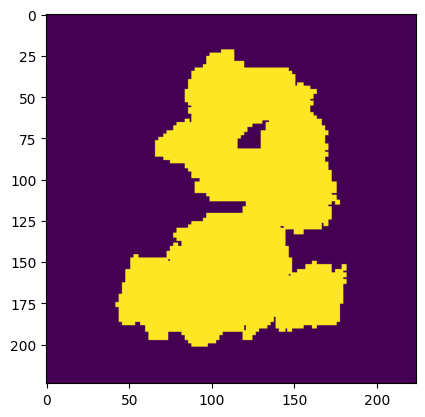

In [ ]:
sample_organoid_id = joined_df.iloc[0]['Organoid_ID']
print(f"sample organoid id is {sample_organoid_id}")
sample_organoid_id = "proseg_expected_CRC_PDO_hImmune_v1_dapi_1CNN_output-XETG00059__0003381__1CNN__20250505__170803_comp24"
plt.imshow(dataset.organoid_masks[sample_organoid_id])

In [ ]:
bbox = dataset.organoid_square_bboxes[sample_organoid_id]
bbox = np.array(bbox) # min_x, min_y, max_x, max_y
print(bbox)

min_x, min_y, max_x, max_y = bbox

[1234. 1283. 1315. 1364.]


In [ ]:
print(max_x - min_x)
print(max_y - min_y)

81.0
81.0


In [ ]:
def transform_bounding_box(bbox, transform_matrix):
    """
    Transform a bounding box using an affine transformation matrix.
    
    Args:
        bbox: Tuple of (min_x, min_y, max_x, max_y) in original coordinate space
        transform_matrix: 3x3 affine transformation matrix for homogeneous coordinates
        
    Returns:
        Tuple of (new_min_x, new_min_y, new_max_x, new_max_y) in transformed space
    """
    min_x, min_y, max_x, max_y = bbox * SCALE_FACTOR
    
    # Define the four corners of the bounding box
    corners = np.array([
        [min_x, min_y, 1],  # bottom-left
        [min_x, max_y, 1],  # top-left  
        [max_x, max_y, 1],  # top-right
        [max_x, min_y, 1]   # bottom-right
    ]).T  # Shape: (3, 4)
    
    # Apply transformation: transform_matrix @ corners
    transformed_corners = transform_matrix @ corners  # Shape: (3, 4)
        
    # Convert from homogeneous to Cartesian coordinates
    transformed_corners = transformed_corners[:2] / transformed_corners[2]  # Shape: (2, 4)
    
    # Find new bounding box by taking min/max of transformed points
    new_min_x = np.min(transformed_corners[0])
    new_min_y = np.min(transformed_corners[1])
    new_max_x = np.max(transformed_corners[0])
    new_max_y = np.max(transformed_corners[1])
    
    return (new_min_x, new_min_y, new_max_x, new_max_y)

In [ ]:
print(bbox)
min_x_histo, min_y_histo, max_x_histo, max_y_histo = transform_bounding_box(bbox, np.linalg.inv(transform_matrix))
print(min_x_histo, min_y_histo, max_x_histo, max_y_histo)

[1234. 1283. 1315. 1364.]
18866.45946525332 9935.381542151761 19800.010089338728 10868.932166237173


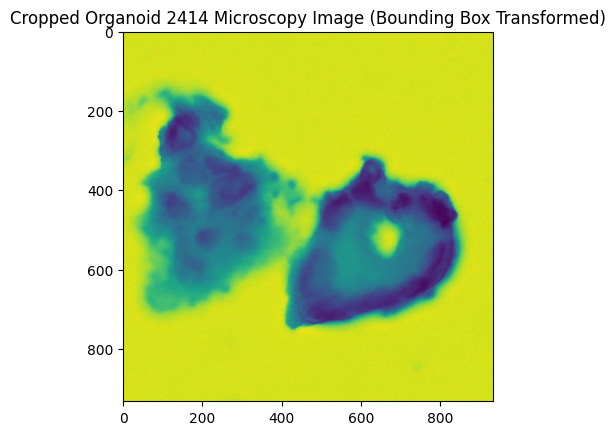

In [ ]:
img = np.mean(microscopy[:, int(min_y_histo):int(max_y_histo), int(min_x_histo):int(max_x_histo)], axis=0)
plt.figure()
plt.title("Cropped Organoid 2414 Microscopy Image (Bounding Box Transformed)")
plt.imshow(img)

In [ ]:
def extract_reoriented_optimized(large_input_image, bbox, transform_matrix, output_size=None):
    """
    Optimized version using cv2.remap on an extracted region.
    """
    min_x, min_y, max_x, max_y = bbox * SCALE_FACTOR
    
    # Step 1: Find the region of interest in the large image
    corners_original = np.array([
        [min_x, min_y, 1],
        [max_x, min_y, 1],
        [max_x, max_y, 1], 
        [min_x, max_y, 1]
    ]).T
    
    corners_transformed = (transform_matrix @ corners_original).T
    corners_transformed = corners_transformed[:, :2] / corners_transformed[:, 2:]
    
    # Find bounds with padding
    x_min = max(0, int(np.floor(np.min(corners_transformed[:, 0]))))
    y_min = max(0, int(np.floor(np.min(corners_transformed[:, 1]))))
    x_max = min(large_input_image.shape[1], int(np.ceil(np.max(corners_transformed[:, 0]))))
    y_max = min(large_input_image.shape[0], int(np.ceil(np.max(corners_transformed[:, 1]))))

    if output_size is None:
        output_size = (x_max - x_min, y_max - y_min)

    # Extract region
    roi = large_input_image[y_min:y_max, x_min:x_max]
    
    if roi.size == 0:
        return np.zeros((output_size[1], output_size[0], large_input_image.shape[2]), 
                       dtype=large_input_image.dtype)
    
    # Step 2: Create coordinate mapping
    # For each pixel in output, where does it map to in the ROI?
    map_x = np.zeros((output_size[1], output_size[0]), dtype=np.float32)
    map_y = np.zeros((output_size[1], output_size[0]), dtype=np.float32)
    
    for y in range(output_size[1]):
        for x in range(output_size[0]):
            # Output pixel → original coordinates
            x_orig = min_x + (x / output_size[0]) * (max_x - min_x)
            y_orig = min_y + (y / output_size[1]) * (max_y - min_y)
            
            # Original coordinates → large image coordinates
            point_orig = np.array([x_orig, y_orig, 1])
            point_img = transform_matrix @ point_orig
            point_img = point_img[:2] / point_img[2]
            
            # Large image coordinates → ROI coordinates
            map_x[y, x] = point_img[0] - x_min
            map_y[y, x] = point_img[1] - y_min
    
    # Step 3: Apply remap to the small ROI
    reoriented = cv2.remap(
        roi,
        map_x,
        map_y,
        interpolation=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0
    )
    
    return (min_x, max_x, min_y, max_y), reoriented

In [ ]:
histo_coords, result = extract_reoriented_optimized(np.moveaxis(microscopy, 0, 2), bbox, np.linalg.inv(transform_matrix))
result.shape

(934, 935, 3)

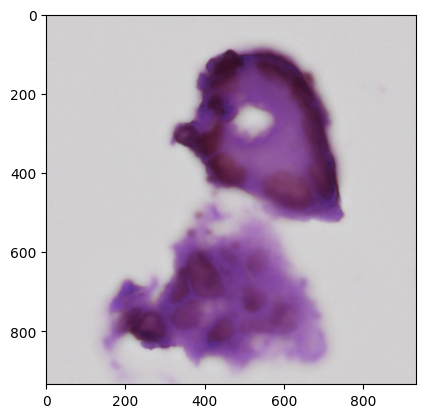

In [ ]:
plt.imshow(result)

In [ ]:


def blend_widget(he_image, mask):
    """Short interpolation widget between H&E image and mask."""
    # Resize H&E to match mask
    he_resized = cv2.resize(he_image, (mask.shape[1], mask.shape[0]))
    
    # Ensure mask is binary and uint8
    mask_binary = (mask > 0).astype(np.uint8) 
    mask_rgb = np.stack([mask_binary * 255] * 3, axis=-1)
    
    @interact(alpha=(0.0, 1.0, 0.01))
    def show_blend(alpha=0.5):
        # Convert to float for blending, then back to uint8
        blended = (alpha * mask_rgb.astype(float) + (1 - alpha) * he_resized.astype(float))
        blended = np.clip(blended, 0, 255).astype(np.uint8)  # Ensure valid range
        
        plt.imshow(cv2.cvtColor(blended, cv2.COLOR_BGR2RGB))
        plt.title(f'Alpha: {alpha:.2f}')
        plt.axis('off')
        plt.show()

# Even shorter one-liner style
def quick_blend(he, mask):
    """Ultra-short version."""
    he = cv2.resize(he, (mask.shape[1], mask.shape[0]))
    mask_rgb = np.stack([((mask > 0).astype(np.uint8)) * 255] * 3, axis=-1)
    
    interact(lambda a=0.5: plt.imshow(cv2.cvtColor(
        cv2.addWeighted(he, 1-a, mask_rgb, a, 0), cv2.COLOR_BGR2RGB)) or plt.show())

In [ ]:
print(result[..., 0].shape)
print(dataset.organoid_masks[sample_organoid_id].shape)
blend_widget(result, dataset.organoid_masks[sample_organoid_id])


(934, 935)
(224, 224)


interactive(children=(FloatSlider(value=0.5, description='alpha', max=1.0, step=0.01), Output()), _dom_classes…

# 3. Generation of Organoid H&E Crops as .ome.tiff pyramidal




In [ ]:
import numpy as np
import tifffile

def write_pyramidal_ome_tiff(array, filename):
    """
    Write a (h, w, ch) numpy array as pyramidal OME-TIFF.
    
    Parameters:
    - array: numpy array with shape (height, width, channels)
    - filename: output filename (.ome.tif)
    """
    with tifffile.TiffWriter(filename, bigtiff=True) as tif:
        tif.write(
            array,
            photometric='rgb' if array.shape[2] in [3, 4] else 'minisblack',
            metadata={'axes': 'YXC'},
            subfiletype=1,  # Reduced resolution
            tile=(256, 256),
        )

write_pyramidal_ome_tiff(result, f"/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/lmcconn1/norkin_organoid/data/organoids_h&e/{sample_organoid_id}.ome.tiff")

# 4. TRIDENT Representation Generation
## 4a. Setup and Settings

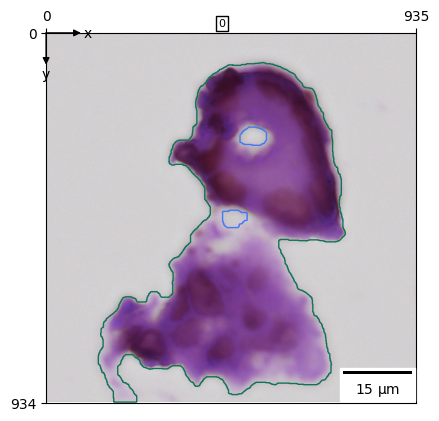

In [ ]:
import lazyslide as zs

from wsidata import open_wsi
wsi = open_wsi(
    "/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/lmcconn1/norkin_organoid/data/organoids_h&e/proseg_expected_CRC_PDO_hImmune_v1_dapi_1CNN_output-XETG00059__0003381__1CNN__20250505__170803_comp24.ome.tiff",
)
wsi.set_mpp(8.625e-2)

zs.pp.find_tissues(wsi)
zs.pp.tile_tissues(wsi, 128)
zs.pl.tissue(wsi)


In [ ]:
wsi['tiles']

,tile_id,tissue_id,geometry
0,0,0,"POLYGON ((260 715, 260 843, 132 843, 132 715, ..."
1,1,0,"POLYGON ((388 587, 388 715, 260 715, 260 587, ..."
2,2,0,"POLYGON ((388 715, 388 843, 260 843, 260 715, ..."
3,3,0,"POLYGON ((516 75, 516 203, 388 203, 388 75, 51..."
4,4,0,"POLYGON ((516 203, 516 331, 388 331, 388 203, ..."
5,5,0,"POLYGON ((516 331, 516 459, 388 459, 388 331, ..."
6,6,0,"POLYGON ((516 459, 516 587, 388 587, 388 459, ..."
7,7,0,"POLYGON ((516 587, 516 715, 388 715, 388 587, ..."
8,8,0,"POLYGON ((516 715, 516 843, 388 843, 388 715, ..."
9,9,0,"POLYGON ((644 75, 644 203, 516 203, 516 75, 64..."


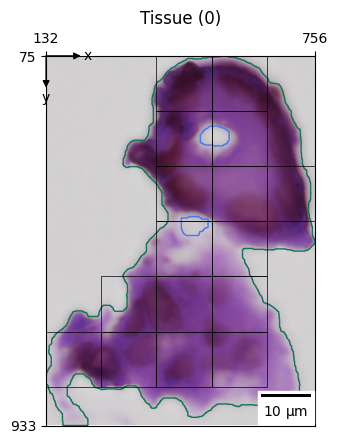

In [ ]:
zs.pl.tiles(wsi, tissue_id="all", linewidth=0.5)

In [ ]:
zs.tl.feature_extraction(wsi, "plip", amp=True)

/work/PRTNR/CHUV/DIR/rgottar1/spatial/conda_envs/lazyslide_env/lib/python3.11/site-packages/lazyslide/models/multimodal/plip.py:24: UserWarning: As from v0.8.2, Normalization will not be applied to image embedding of PLIP model anymore.A `normalize=True` argument is added to the `text_image_similarity` method.If you only use the image embedding for text image similarity, you can safely ignore this warning.
  warnings.warn(


Output()

In [ ]:
adata = wsi.fetch.features_anndata("plip")

In [ ]:
adata.obsm['spatial']

array([[132., 715.],
       [260., 587.],
       [260., 715.],
       [388.,  75.],
       [388., 203.],
       [388., 331.],
       [388., 459.],
       [388., 587.],
       [388., 715.],
       [516.,  75.],
       [516., 203.],
       [516., 331.],
       [516., 459.],
       [516., 587.],
       [516., 715.],
       [644., 331.]])

# 4b. Generation

# 5. Patch Analysis
## 5a.Pooling
## 5b. UMAP 